# 🚗 Used Car Market Analysis using Pandas & NumPy

## Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a used car dataset using Pandas and NumPy.

The project includes:
- Data Cleaning
- Handling Missing Values
- Type Conversion
- Exploratory Data Analysis
- Statistical Analysis
- Business Insights

In [114]:
import pandas as pd
import numpy as n
import matplotlib.pyplot as mat
import seaborn as sea

## Loading the Dataset

In [115]:
df = pd.read_csv("car details v4.csv")
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


## Dataset Overview

Let's understand the dataset by checking its structure, data types and statistical summary.

In [116]:

print('\n','\n','study the data informations')
print(df.info()) # getting the information about dataset

print(' taking dataset static descrition, shape, columns names, with top five and bottom five rows')
print(df.describe(),'\n', df.shape,'\n', df.tail(10),'\n', df.head(10), "\n", df.columns)
 # study dataset static descrition, shape, columns names, and first five and last five rows

print('datatypes of each column')
print(df.dtypes) # datatypes of columns

  


 
 study the data informations
<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              1979 non-null   str    
 12  Max Power           1979 non-null   str    
 13  Max Torque          1979 non-null   str    
 14  Drivetrain          1923 non-null   str    
 15  Length              1995 non-null 

# Data Cleaning and type convert from str to float


In [117]:
#  checking for missing or improper data
print('looking for improper data in the dataset')
for col in df.columns:
  print(df[col].head())

looking for improper data in the dataset
0            Honda
1    Maruti Suzuki
2          Hyundai
3           Toyota
4           Toyota
Name: Make, dtype: str
0                Amaze 1.2 VX i-VTEC
1                    Swift DZire VDI
2               i10 Magna 1.2 Kappa2
3                           Glanza G
4    Innova 2.4 VX 7 STR [2016-2020]
Name: Model, dtype: str
0     505000
1     450000
2     220000
3     799000
4    1950000
Name: Price, dtype: int64
0    2017
1    2014
2    2011
3    2019
4    2018
Name: Year, dtype: int64
0    87150
1    75000
2    67000
3    37500
4    69000
Name: Kilometer, dtype: int64
0    Petrol
1    Diesel
2    Petrol
3    Petrol
4    Diesel
Name: Fuel Type, dtype: str
0    Manual
1    Manual
2    Manual
3    Manual
4    Manual
Name: Transmission, dtype: str
0         Pune
1     Ludhiana
2      Lucknow
3    Mangalore
4       Mumbai
Name: Location, dtype: str
0      Grey
1     White
2    Maroon
3       Red
4      Grey
Name: Color, dtype: str
0     First
1   

In [118]:
print("**************organised the data properly*************")
print('removing the unit and chage tha data in the numberical types')
df['Engine'] = df['Engine'].str.replace('cc','')
print(df['Engine']) # removing 'cc'
df['Engine'] = df['Engine'].astype(float)
print(df['Engine'].dtype)
print('extraxted the numberical data only')
df['Max Power'] = df['Max Power'].str.extract(r'(\d+)')
print(df['Max Power']) # Extracted only numberical data

**************organised the data properly*************
removing the unit and chage tha data in the numberical types
0       1198 
1       1248 
2       1197 
3       1197 
4       2393 
        ...  
2054    2179 
2055     814 
2056    1196 
2057    1995 
2058    1493 
Name: Engine, Length: 2059, dtype: str
float64
extraxted the numberical data only
0        87
1        74
2        79
3        82
4       148
       ... 
2054    138
2055     55
2056     70
2057    188
2058     70
Name: Max Power, Length: 2059, dtype: str


In [119]:
# type convert from str to float
df['Max Power'] = df['Max Power'].astype(float) 
df['Max Torque'] = df['Max Torque'].str.extract(r'(\d+)')
df['Max Torque'] = df['Max Torque'].astype(float)


### Missing Values

In [120]:
print('seek for missing data')
print(df.isnull().sum())
print(df.dtypes)


seek for missing data
Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64
Make                      str
Model                     str
Price                   int64
Year                    int64
Kilometer               int64
Fuel Type                 str
Transmission              str
Location                  str
Color                     str
Owner                     str
Seller Type               str
Engine                float64
Max Power             float64
Max Torque            float64
Drivetrain               

* Dealing with missig value

In [121]:
print( 'removing the Drivetrai column from dataset ')
df.drop(columns=['Drivetrain'], inplace= True)

removing the Drivetrai column from dataset 


In [122]:
# rechecking current staus of dataset
print(' recheck point')
print(df.columns)


 recheck point
Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='str')


In [123]:
# filling the missing data
print('filling the null values')
df.fillna(0, inplace = True)
# rechecking
print('rechecking for null value')
print(df.isnull().sum())

filling the null values
rechecking for null value
Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
dtype: int64


### Duplicate Values

In [124]:
print(df.duplicated().sum())

0


# Company Analysis

In [125]:
cars = df["Make"].value_counts().sort_values(ascending=False).head()
print(cars)

Make
Maruti Suzuki    440
Hyundai          349
Mercedes-Benz    171
Honda            158
Toyota           132
Name: count, dtype: int64


### Observation

Maruti Suzuki has the highest number of listed used cars in this dataset.

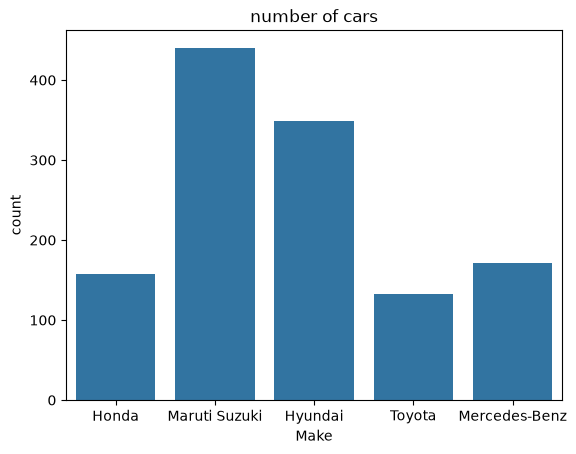

In [126]:
data = df.loc[ df["Make"].isin(cars.index)]
sea.countplot(data=data, x= data['Make'])
mat.title("number of cars")
mat.show()

* price analysis

In [127]:
H_S=df.groupby("Make")["Price"].mean().sort_values(ascending=False)


### Observation

Mercedes-Benz has the highest average selling price among all manufacturers in this dataset with 749810995 rs  .

In [ ]:
print(" the Averge price by company ")
print(H_S)
print(f" the most Expensive company is {H_S.idxmax()} with total {H_S.max()} price")
#  Mercedes-Benz with  749810995 price  is the most expensive company according to this dataset
print(f" The cheapest company is {H_S.idxmin()} with total {H_S.min()} price")
# The Fiat is the cheapest company with 61000 price



 the Averge price by company 
Make
Ferrari          3.500000e+07
Lamborghini      2.400000e+07
Rolls-Royce      1.933333e+07
Maserati         9.000000e+06
Porsche          8.342667e+06
Land Rover       6.699333e+06
Mercedes-Benz    4.384860e+06
Lexus            4.125000e+06
BMW              3.768967e+06
Jaguar           3.564647e+06
Volvo            3.090875e+06
MINI             3.054909e+06
Audi             2.703134e+06
MG               2.024118e+06
Jeep             1.956889e+06
Isuzu            1.945500e+06
Toyota           1.729545e+06
Kia              1.569913e+06
Skoda            1.498225e+06
Ford             1.474625e+06
Mitsubishi       1.348750e+06
Mahindra         1.083479e+06
Tata             9.907368e+05
Ssangyong        8.500000e+05
Hyundai          7.232635e+05
Volkswagen       7.074599e+05
Honda            6.221076e+05
Maruti Suzuki    5.348000e+05
Nissan           4.821875e+05
Renault          4.695813e+05
Chevrolet        3.412856e+05
Fiat             3.050000e+05
Datsu

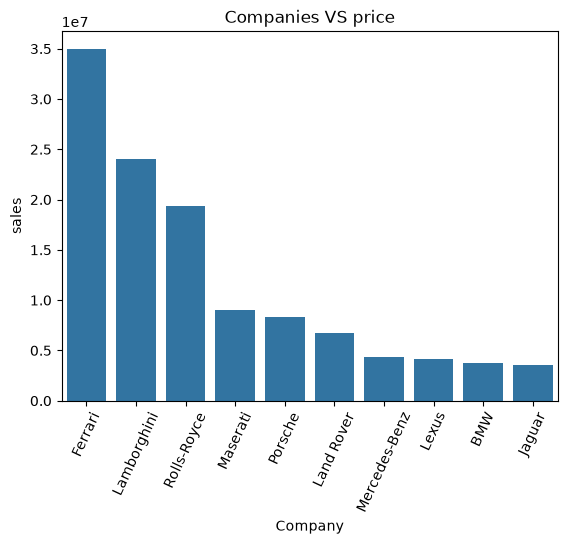

In [155]:
H_SS=df.groupby("Make")["Price"].mean().sort_values(ascending=False).head(10)
mat.Figure(figsize=(9,9))
sea.barplot( x=H_SS.index, y=H_SS.values)
mat.xticks(rotation = 65)
mat.xlabel("Company")
mat.ylabel("sales")
mat.title("Companies VS price")
mat.show()

# Fuel Type Analysis

In [156]:
F_A = df.groupby('Fuel Type')['Make'].count().sort_values(ascending= False)

print('the fuel comparison','\n',f'the petrol user are { F_A.loc['Petrol']}','\n',f'while the Diesel user are { F_A.loc['Diesel']}')
print(F_A)

the fuel comparison 
 the petrol user are 942 
 while the Diesel user are 1049
Fuel Type
Diesel          1049
Petrol           942
CNG               50
Electric           7
LPG                5
Hybrid             3
CNG + CNG          1
Petrol + CNG       1
Petrol + LPG       1
Name: Make, dtype: int64


               Make                                  Model    Price  Year  \
0             Honda                    Amaze 1.2 VX i-VTEC   505000  2017   
1     Maruti Suzuki                        Swift DZire VDI   450000  2014   
2           Hyundai                   i10 Magna 1.2 Kappa2   220000  2011   
3            Toyota                               Glanza G   799000  2019   
4            Toyota        Innova 2.4 VX 7 STR [2016-2020]  1950000  2018   
...             ...                                    ...      ...   ...   
2054       Mahindra                  XUV500 W8 [2015-2017]   850000  2016   
2055        Hyundai                           Eon D-Lite +   275000  2014   
2056           Ford            Figo Duratec Petrol ZXI 1.2   240000  2013   
2057            BMW  5-Series 520d Luxury Line [2017-2019]  4290000  2018   
2058       Mahindra      Bolero Power Plus ZLX [2016-2019]   670000  2017   

      Kilometer Fuel Type Transmission    Location   Color   Owner  \
0    

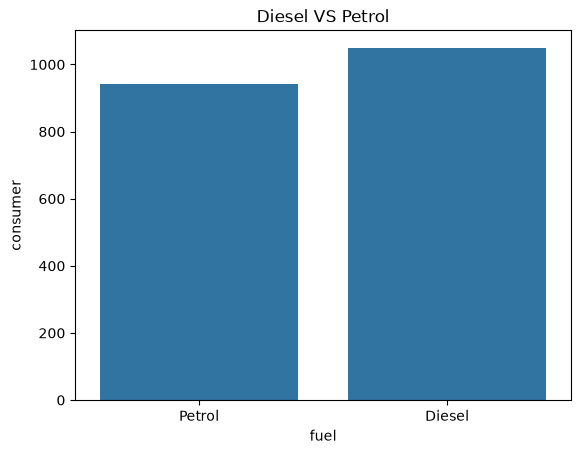

In [157]:
fuel = ["Diesel","Petrol"]
fuel_data = df.loc[df["Fuel Type"].isin(fuel)]
print(fuel_data)
sea.countplot(data= fuel_data, x= fuel_data["Fuel Type"])
mat.title("Diesel VS Petrol")
mat.xlabel("fuel")
mat.ylabel("consumer")
mat.show()

### owner Analysis

In [158]:
O_A = df.groupby("Owner")['Model'].count().sort_values(ascending= False)

print("The Owner Count...")
print(O_A)
print(f' the highest owner type is {O_A.idxmax()} with {O_A.max()} cars counts')
print(f' the lowest owner type is {O_A.idxmin()} with {O_A.min()} cars counts')
F_A = df.groupby('Fuel Type')['Make'].count().sort_values(ascending= False)
print('Average price by owner')
A_P_O = df.groupby('Owner')['Price'].mean().sort_values(ascending= False)
print(A_P_O)

The Owner Count...
Owner
First               1619
Second               373
Third                 42
UnRegistered Car      21
Fourth                 3
4 or More              1
Name: Model, dtype: int64
 the highest owner type is First with 1619 cars counts
 the lowest owner type is 4 or More with 1 cars counts
Average price by owner
Owner
UnRegistered Car    5.285333e+06
Third               1.981929e+06
First               1.714159e+06
Second              1.438051e+06
Fourth              1.633333e+05
4 or More           1.200000e+05
Name: Price, dtype: float64


# Engine Analysis

In [159]:
print(f" the Engine size {df['Engine'].mean()}")

largest = df.loc[df["Engine"].idxmax()]
print(f"Largest engine: {largest['Engine']} cc")
print(f"Car: {largest['Make']} {largest['Model']}")

smallest = df.loc[df["Engine"].idxmin()]
print(f"smallet engine: {smallest['Engine']} cc")
print(f"Car: {largest['Make']} {largest['Model']}")

 the Engine size 1626.812530354541
Largest engine: 6592.0 cc
Car: Rolls-Royce Ghost 6.5
smallet engine: 0.0 cc
Car: Rolls-Royce Ghost 6.5


### Observation

The average engine size is approximately 1627 cc.

# City Analysis

In [160]:
lo = df.groupby("Location")['Price'].sum().sort_values(ascending= False)

print(' The Location V/S price ')
print(lo)
print(f'the highest prices {lo.max()} on {lo.idxmax()} ')
print(f'the cheapest prices {lo.min()} on {lo.idxmax()}')

l_c = df.groupby('Location')['Model'].count().sort_values(ascending= False)

print(' Where is the city with most cars')
print(l_c)
print(f' the most of cars on { l_c.idxmax()} with total {l_c.max()} cars')


 The Location V/S price 
Location
Delhi               793628985
Mumbai              588776984
Pune                284797998
Bangalore           267790991
Hyderabad           241253992
                      ...    
Deoghar                545000
Pimpri-Chinchwad       330000
Unnao                  259999
Faizabad               240000
Siliguri               204999
Name: Price, Length: 77, dtype: int64
the highest prices 793628985 on Delhi 
the cheapest prices 204999 on Delhi
 Where is the city with most cars
Location
Mumbai              342
Delhi               307
Pune                144
Bangalore           132
Hyderabad           116
                   ... 
Faizabad              1
Pimpri-Chinchwad      1
Rohtak                1
Siliguri              1
Valsad                1
Name: Model, Length: 77, dtype: int64
 the most of cars on Mumbai with total 342 cars


# Transmission

In [161]:
mil = df.groupby('Fuel Type')["Kilometer"].mean()
print(mil)
Tra = df.groupby('Transmission')["Make"].count().sort_values(ascending=False)
print(' the Transmission list')
print(Tra)

T_P =  df.groupby('Transmission')['Price'].mean().sort_values(ascending= False)


Fuel Type
CNG              51718.780000
CNG + CNG        56843.000000
Diesel           65094.080076
Electric         19842.857143
Hybrid           15000.000000
LPG              55044.200000
Petrol           42574.409766
Petrol + CNG     58000.000000
Petrol + LPG    100000.000000
Name: Kilometer, dtype: float64
 the Transmission list
Transmission
Manual       1133
Automatic     926
Name: Make, dtype: int64


# Observation

Transmission
Manual       1133
Automatic     926

# price analysis

In [162]:
EX = df.groupby('Model')["Price"].max()

print(f'the most expensive car is  {EX.idxmax()} with {EX.max()} ')

Ch = df.groupby('Model')["Price"].min()

print(f'the most expensive car is  {Ch.idxmin()} with {Ch.min()} ')

Med = df.groupby('Model')["Price"].median()

print("Median of the cars", '\n', Med)

print(' The distribution','\n',df['Price'].describe())


the most expensive car is  488 GTB with 35000000 
the most expensive car is  Nano Base with 49000 
Median of the cars 
 Model
2 Series Gran Coupe 220d M Sport [2020-2021]    4200000.0
3-Series 320d                                    800000.0
3-Series 320d Highline Sedan                    1200000.0
3-Series 320d Luxury Edition                    4550000.0
3-Series 320d Luxury Line                       2232499.5
                                                  ...    
i20 Magna 1.4 CRDI                               340000.0
i20 Sportz 1.2                                   375000.0
i20 Sportz 1.2 (O)                               305000.0
i20 Sportz 1.2 BS-IV                             350000.0
i20 Sportz 1.4 CRDI                              409999.0
Name: Price, Length: 1050, dtype: float64
 The distribution 
 count    2.059000e+03
mean     1.702992e+06
std      2.419881e+06
min      4.900000e+04
25%      4.849990e+05
50%      8.250000e+05
75%      1.925000e+06
max      3.500000e+0

# Average Price by Top 10

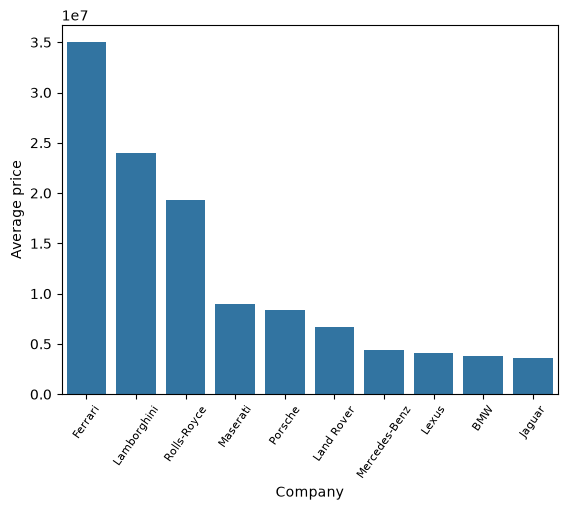

In [ ]:
Avg_price = df.groupby("Make")["Price"].mean().sort_values(ascending= False).head(10)
mat.Figure(figsize=(9,9))
sea.barplot(x=Avg_price.index,y=Avg_price.values)
mat.xlabel("Company")
mat.ylabel("Average price")
mat.title("Top 10 Cars by Average Price ")
mat.xticks(rotation = 55, fontsize = 8)
mat.show()

# Engine Size vs Price

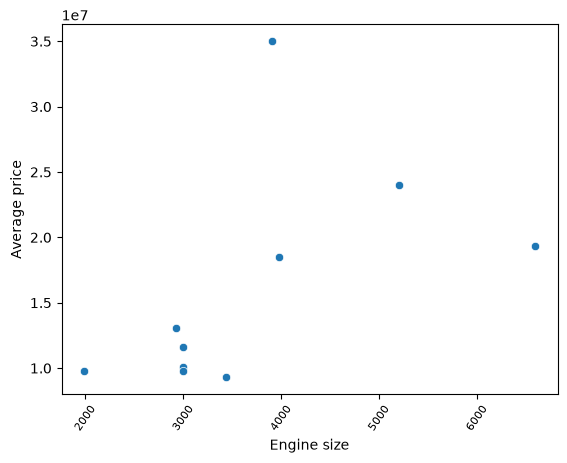

In [ ]:
E_VS_P = df.groupby("Engine")["Price"].mean().sort_values(ascending= False).head(10)
mat.Figure(figsize=(9,9))
sea.scatterplot(x= E_VS_P.index,y=E_VS_P.values)
mat.xlabel("Engine size")
mat.ylabel("Average price")
mat.title("Engine Size vs Price")
mat.xticks(rotation = 55, fontsize = 8)
mat.show()

Average Price by Fuel Type

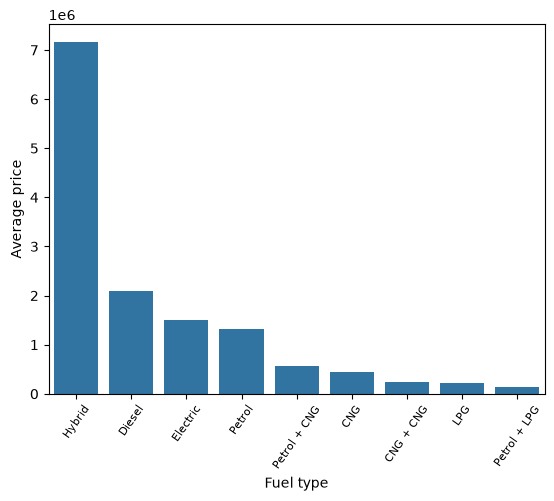

In [ ]:
Avg_price_by_fuel = df.groupby("Fuel Type")["Price"].mean().sort_values(ascending= False).head(10)
mat.Figure(figsize=(9,9))
sea.barplot(x=Avg_price_by_fuel.index,y=Avg_price_by_fuel.values)
mat.xlabel("Fuel type")
mat.ylabel("Average price")
mat.title("Average Price by Fuel Type")
mat.xticks(rotation = 55, fontsize = 8)
mat.show()

# Fuel Type Distribution

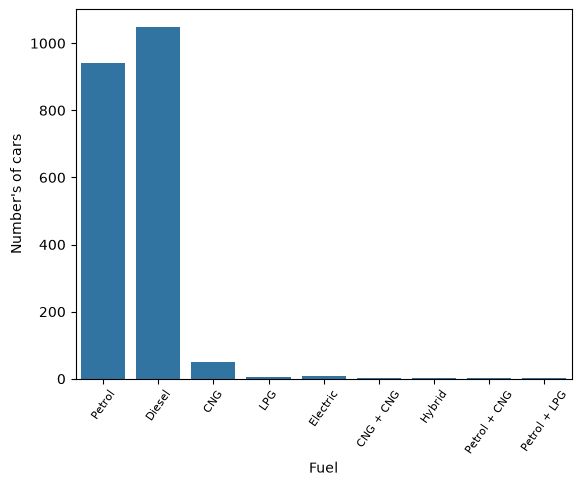

In [ ]:
mat.Figure(figsize=(9,9))
sea.countplot(data=df, x="Fuel Type")
mat.xlabel("Fuel")
mat.ylabel("Number's of cars")
mat.title("Fuel Type Distribution")
mat.xticks(rotation = 55, fontsize = 8)
mat.show()

# numpy  

In [167]:
price = df['Price'].to_numpy()

print(f" Avrager: {n.mean(price)}")

print(f" standard Deviations: {n.std(price)}")
print(f" median: {n.median(price)}")
print(f" maximun: {n.max(price)}")
print(f" Minimun: {n.min(price)}")
print(f" Variance {n.var(price)}")

print(f" percentile of","\n",f" 25% = {n.percentile(price,25)}","\n",f" 50% = {n.percentile(price,50)}","\n",f" 75% = {n.percentile(price,75)}")

 Avrager: 1702991.6964545897
 standard Deviations: 2419292.9291388267
 median: 825000.0
 maximun: 35000000
 Minimun: 49000
 Variance 5852978276981.123
 percentile of 
  25% = 484999.0 
  50% = 825000.0 
  75% = 1925000.0


# Conclusion

This project demonstrates the use of Pandas and NumPy to clean, transform and analyze a real-world used car dataset.

Skills demonstrated:

- Data Cleaning
- Data Transformation
- Missing Value Handling
- GroupBy Operations
- Sorting
- Aggregation
- Exploratory Data Analysis